<center>
<h1>COMP3242/6242: Deep Learning</h1>
<h2>Lab #5: Image Segmentation</h2>
Semester 1, 2026<br>
</center>

**Due**: 11:59pm on Sunday 29 March, 2026.<br>

Submit solutions as a single Jupyter Notebook via Canvas. Make sure that your name and student ID appears in the section below. You may not work with any other person in completing this laboratory. You must acknowledge any non-course texts or online material used. See the course policy on the use of generative AI tools such as ChatGPT and Claude.

This assignment will be **automatically graded**. Read and follow instructions carefully!

Test code is provided for you to check your work as you progress through the assignment. Feel free to add further tests and output useful for your own debugging. Note that this code will not be run when we automatically grade your submission. We will exercise your code beyond what is provided here. Do not add any Jupyter notebook magic commands (i.e., those starting with `%` or `%%`). These may cause the autograding script to fail.

Complete all **TODOs** and delete any placeholder (`pass` and `...`). Wrap any additional non-TODO related code (e.g., your own tests) in an ``if is_notebook():'' conditional to avoid issues with our automated grading scripts.

**Run all code blocks from start to end (`Restart & Run All`) and then save your Jupyter Notebook before submitting your assignment to ensure everything works as expected.**

In [10]:
# TODO: Replace with your name and university ID
student_name = "Razeen Wasif"
student_id = "u7283652"

## Disclosure

TODO: document any use of online resources (other than course material) and/or generative AI tools.

In [11]:
# The ANU lab machines will have python and the necessary packages already installed. If you're working
# on your own machine you will need to install python with Jupyter notebook and PyTorch:
#  - Documentation for the PyTorch deep learning library is here: https://pytorch.org/. Follow the
#    installation instructions (for the stable release), being sure to install both `pytorch` and
#    `torchvision`. You will not need access to a GPU for this course but having one may increase
#    computation speed.
#  Browse through the user documentation and tutorials for these libraries.

import json
import sys
import getpass
from pathlib import Path


def is_notebook():
    return 'ipykernel' in sys.modules


import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import trange

if is_notebook():
    print("User: {} ({}, {})".format(getpass.getuser(), student_name, student_id))
    print("Python Version: {}".format(sys.version))
    print("PyTorch Version: {}".format(torch.__version__))

User: ryujin (Razeen Wasif, u7283652)
Python Version: 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
PyTorch Version: 2.11.0+cu130


In [12]:
device = torch.device("cpu")
random_seed = 3242
torch.manual_seed(random_seed)
np.random.seed(random_seed)

DATA_ROOT = Path('./data')

## Task 1: Complete `__getitem__` in the Dataset Class

In this task, you will finish the data loading pipeline by implementing `__getitem__(idx)` in `SegmentationDataset`.

### Your goal
For a given index `idx`, return one training example as:

- `image_tensor`: image tensor with shape `(3, 256, 256)`
- `mask_tensor`: segmentation label tensor with shape `(256, 256)` and dtype `torch.long`

### What is already provided
You already have helper methods and paths set up:

- `self.image_paths` and `self.mask_paths`
- `process_image(...)`
- `process_segmentation_map(...)`

### What you need to do in `__getitem__`
1. Read the image path and mask path at index `idx`.
2. Process the image with `process_image(...)`.
3. Process the mask with `process_segmentation_map(...)`.
4. Return `(image_tensor, mask_tensor)`.

Expected dataset layout under the dataset root directory:

- `images/`
- `masks/`

Image and mask filenames should match by stem (for example `7.png` in both folders).

All image/mask pairs in these folders are used as training data.

In this repo, the dataset root is typically `labs/05/data`.

In [13]:
class SegmentationDataset(Dataset):
    def __init__(self, root: str | Path, split: str, image_size: int = 256):
        self.root = Path(root)
        self.split = split
        self.image_size = image_size

        images_root = self.root / 'images'
        masks_root = self.root / 'masks'

        self.class_names = ['background', 'car', 'person', 'road']
        self.num_classes = len(self.class_names)
        self.colour_encodings = {
            'car': torch.tensor([0, 0, 142]),
            'person': torch.tensor([255, 0, 0]),
            'road': torch.tensor([128, 64, 128]),
        }

        all_image_paths = sorted(list(images_root.glob('*.png')) + list(images_root.glob('*.jpg')))
        all_mask_paths = {p.stem: p for p in masks_root.glob('*.png')}
        paired = [(img, all_mask_paths[img.stem]) for img in all_image_paths if img.stem in all_mask_paths]
        assert len(paired) > 0, f'No aligned image/mask pairs found in {images_root} and {masks_root}'

        if split != 'train':
            raise ValueError("Only split='train' is supported in this notebook")

        self.image_paths = [p[0] for p in paired]
        self.mask_paths = [p[1] for p in paired]

        self.image_transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])

    def process_segmentation_map(self, mask_path: str | Path) -> torch.Tensor:
        mask = Image.open(mask_path).convert('RGBA')
        mask = mask.resize((self.image_size, self.image_size), resample=Image.NEAREST)
        arr = np.array(mask)[..., :3]  # ignore alpha channel

        label = np.zeros((arr.shape[0], arr.shape[1]), dtype=np.int64)

        car = np.all(arr == self.colour_encodings['car'].numpy().reshape(1, 1, 3), axis=-1)
        person = np.all(arr == self.colour_encodings['person'].numpy().reshape(1, 1, 3), axis=-1)
        road = np.all(arr == self.colour_encodings['road'].numpy().reshape(1, 1, 3), axis=-1)

        label[car] = 1
        label[person] = 2
        label[road] = 3

        return torch.from_numpy(label).long()

    def process_image(self, image_path: str | Path) -> torch.Tensor:
        image = Image.open(image_path).convert('RGB')
        return self.image_transform(image)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        # TODO: TASK 1
        # Implement item loading using:
        #   - self.image_paths[idx]
        #   - self.mask_paths[idx]
        #   - self.process_image(...)
        #   - self.process_segmentation_map(...)
        # Return (image_tensor, mask_tensor)
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        image_tensor = self.process_image(img_path)
        mask_tensor = self.process_segmentation_map(mask_path)
        return image_tensor, mask_tensor

Dataset root: /home/ryujin/GitHub/Machine_Learning/Deep-Learning/lab05/data
Num train samples: 13
Classes: ['background', 'car', 'person', 'road']


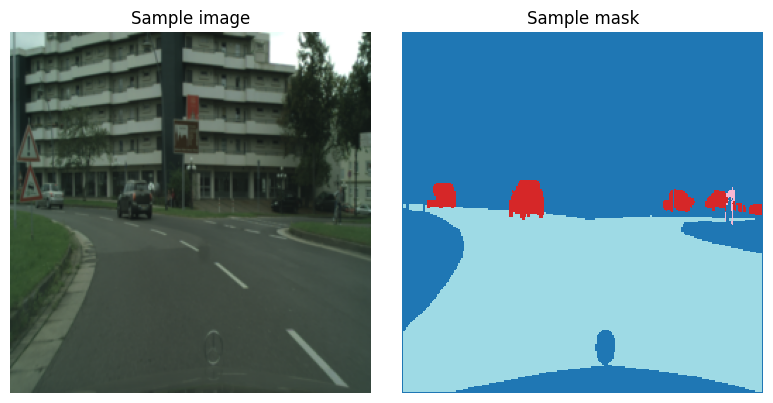

Task 1 (__getitem__) check passed!


In [14]:
if is_notebook():
    data_root = DATA_ROOT

    train_data = SegmentationDataset(data_root, split='train', image_size=256)

    print(f'Dataset root: {data_root.resolve()}')
    print(f'Num train samples: {len(train_data)}')
    print(f'Classes: {train_data.class_names}')

    # Task 1 check: this should work only after __getitem__ is implemented.
    x0, y0 = train_data[0]

    assert x0.ndim == 3 and x0.shape[0] == 3
    assert y0.ndim == 2 and y0.dtype == torch.long
    assert int(y0.max()) < train_data.num_classes

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(np.transpose(x0.numpy(), (1, 2, 0)))
    axes[0].set_title('Sample image')
    axes[0].axis('off')

    axes[1].imshow(y0.numpy(), cmap='tab20', interpolation='nearest')
    axes[1].set_title('Sample mask')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    print('Task 1 (__getitem__) check passed!')

## Task 2: Build the U-Net Encoder

In this task, you will build the encoder path of a U-Net using convolution blocks and max-pooling.

Use this channel and shape plan:

- Input image shape: `(B, 3, 256, 256)`
- Encoder blocks:
  - Block 1: `3 -> 64`
  - Block 2: `64 -> 128`
  - Block 3: `128 -> 256`
- Bottleneck convolutions:
  - `256 -> 512 -> 512`

Your `UNetEncoder.forward(...)` should return:

- `skip1`: `(B, 64, 256, 256)`
- `skip2`: `(B, 128, 128, 128)`
- `skip3`: `(B, 256, 64, 64)`
- `bottleneck`: `(B, 512, 32, 32)`

In [15]:
# --- TASK 2 -------------------------------------------------------------------------------------
class ConvBlock(nn.Module):
    def __init__(self, in_ch: int, out_ch: int):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)


class UNetEncoder(nn.Module):
    def __init__(self, in_channels: int = 3):
        super().__init__()
        # TODO: define encoder blocks and downsampling.
        self.block1 = ConvBlock(in_channels, 64)
        self.block2 = ConvBlock(64, 128)
        self.block3 = ConvBlock(128, 256)
        
        # bottleneck uses two convolutions to reach 512 channels 
        self.bottleneck_conv1 = nn.Conv2d(256, 512, kernel_size=3, padding=1) 
        self.bottleneck_conv2 = nn.Conv2d(512, 512, kernel_size=3, padding=1) 

        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
        # TODO: return (skip1, skip2, skip3, bottleneck)
        skip1 = self.block1(x) # 256x256 
        x = self.pool(skip1) # downsample to 128x128

        skip2 = self.block2(x) # 128x128
        x = self.pool(skip2) # downsample to 64x64

        skip3 = self.block3(x) # 64x64 
        x = self.pool(skip3) # downsample to 32x32

        # bootleneck at 32x32 
        x = self.relu(self.bottleneck_conv1(x))
        bottleneck = self.relu(self.bottleneck_conv2(x))
        return skip1, skip2, skip3, bottleneck



## Task 3: Build the U-Net Decoder

Now build the decoder path that upsamples bottleneck features and fuses them with skip connections from the encoder.

Use this decoder channel plan:

- `512 -> 256`
- `256 -> 128`
- `128 -> 64`

Your `UNetDecoder` should:

- upsample with transposed convolutions (`kernel_size=2, stride=2`)
- concatenate skip features along the channel dimension
- apply convolution blocks after each concatenation
- return a feature map of shape `(B, 64, 256, 256)`

Tip: check channel counts carefully after each concat operation.

In [16]:
# --- TASK 3 -------------------------------------------------------------------------------------
# Task 3: Implement the Decoder
class UNetDecoder(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: define upsampling + fusion blocks.
        self.up1 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(512, 256)
        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2) 
        self.dec2 = ConvBlock(256, 128)
        self.up3 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) 
        self.dec3 = ConvBlock(128, 64)

    def forward(
        self,
        skip1: torch.Tensor,
        skip2: torch.Tensor,
        skip3: torch.Tensor,
        bottleneck: torch.Tensor,
    ) -> torch.Tensor:
        # TODO: decode with skip connections and return feature map of shape (B, 64, 256, 256)
        x = self.up1(bottleneck)
        x = torch.cat([x, skip3], dim=1) 
        x = self.dec1(x) 

        x = self.up2(x)
        x = torch.cat([x, skip2], dim=1) 
        x = self.dec2(x) 

        x = self.up3(x)
        x = torch.cat([x, skip1], dim=1) 
        x = self.dec3(x) 
        
        return x

## Task 4: Assemble U-Net and Train

In this final core task, connect your encoder and decoder into a complete U-Net and train it on the packaged dataset.

You need to complete:

- **Task 4A**: `UNet` initialisation and forward pass
- **Task 4B**: training/evaluation run using `train_one_epoch(...)` and `evaluate_model(...)`

Use this U-Net channel specification:

- Encoder path: `3 -> 64 -> 128 -> 256`
- Bottleneck: `256 -> 512 -> 512`
- Decoder path: `512 -> 256 -> 128 -> 64`
- Final classifier: `64 -> num_classes`

Input/output shape target:

- input: `(B, 3, 256, 256)`
- logits: `(B, num_classes, 256, 256)`

When your implementation is complete, the notebook should:

- pass architecture shape checks
- train for a short CPU run
- show epoch-wise training loss
- visualise one prediction and per-class binary segmentation masks

In [17]:
# --- TASK 4A ------------------------------------------------------------------------------------
class UNet(nn.Module):
    def __init__(self, num_classes: int, in_channels: int = 3):
        super().__init__()
        # TODO: instantiate encoder and decoder modules from Task 2 and Task 3.
        # Required dimensions:
        # - encoder: 3 -> 64 -> 128 -> 256, then bottleneck 256 -> 512 -> 512
        # - decoder: 512 -> 256 -> 128 -> 64
        # - classifier: Conv2d(64, num_classes, kernel_size=1)
        self.encoder = UNetEncoder()
        self.decoder = UNetDecoder()
        self.classifier = nn.Conv2d(64, num_classes, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: run encoder, decoder, classifier and return logits
        skip1, skip2, skip3, bottleneck = self.encoder(x) 
        x = self.decoder(skip1, skip2, skip3, bottleneck)
        logits = self.classifier(x) 
        return logits


# --- TASK 4B ------------------------------------------------------------------------------------
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    device: torch.device = device,
) -> float:
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    return running_loss / len(loader)


def evaluate_model(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device = device,
) -> float:
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)
            logits = model(images)
            total_loss += criterion(logits, masks).item()

    return total_loss / len(loader)

In [18]:
if is_notebook():
    # Task 2/3/4 architecture checks
    dummy_x = torch.randn(2, 3, 256, 256)

    enc = UNetEncoder(in_channels=3)
    s1, s2, s3, b = enc(dummy_x)
    assert s1.shape == (2, 64, 256, 256), 'Task 2 failed: skip1 shape mismatch'
    assert s2.shape == (2, 128, 128, 128), 'Task 2 failed: skip2 shape mismatch'
    assert s3.shape == (2, 256, 64, 64), 'Task 2 failed: skip3 shape mismatch'
    assert b.shape == (2, 512, 32, 32), 'Task 2 failed: bottleneck shape mismatch'

    dec = UNetDecoder()
    f = dec(s1, s2, s3, b)
    assert f.shape == (2, 64, 256, 256), 'Task 3 failed: decoder output shape mismatch'

    model = UNet(num_classes=5, in_channels=3)
    logits = model(dummy_x)
    assert logits.shape == (2, 5, 256, 256), 'Task 4 failed: U-Net output shape mismatch'

    print('Task 2/3/4 architecture tests passed!')

Task 2/3/4 architecture tests passed!


## Training and Visualisation

After you complete Task 4, run the next three cells in order:

1. **Training cell**: trains the model on all image/mask pairs and stores the epoch losses.
2. **Loss visualisation cell**: plots the training loss curve.
3. **Result visualisation cell**: runs prediction on `data/test_image.png` and shows the predicted mask plus per-class binary masks.

This may take a few minutes to complete. A progress bar will show indicate percentage complete.

In [34]:
if is_notebook():
    # Training
    data_root = DATA_ROOT
    train_data = SegmentationDataset(data_root, split='train', image_size=256)

    batch_size = 1
    max_epochs = 60

    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    model = UNet(num_classes=train_data.num_classes, in_channels=3).to(device)
    optimizer = torch.optim.Adam(params=model.parameters())
    criterion = nn.CrossEntropyLoss()
    losses = []

    epoch_bar = trange(max_epochs, desc='Loss pending...', leave=True)
    for epoch in epoch_bar:
        running = 0.0
        for images, masks in train_loader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, masks)
            loss.backward()
            optimizer.step()

            running += loss.item() * (images.shape[0] / len(train_data))

        losses.append(running)
        epoch_bar.set_description(f'Training Loss at Epoch {epoch}: {running:.4f}')
        epoch_bar.refresh()

Training Loss at Epoch 59: 0.6174: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 60/60 [10:48<00:00, 10.80s/it]


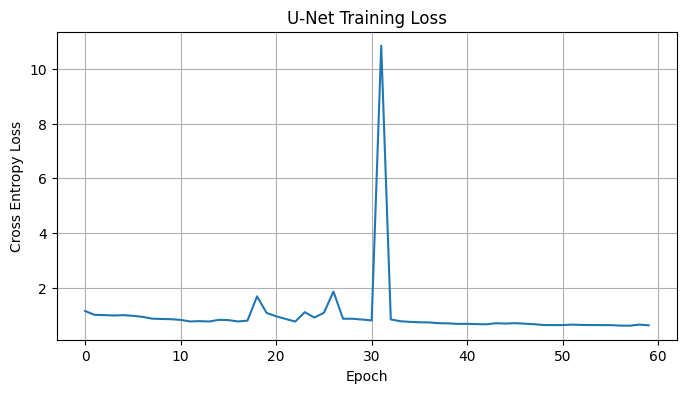

In [35]:
if is_notebook():
    # Loss visualisation
    plt.figure(figsize=(8, 4))
    plt.plot(losses)
    plt.title('U-Net Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Cross Entropy Loss')
    plt.grid(True)
    plt.show()

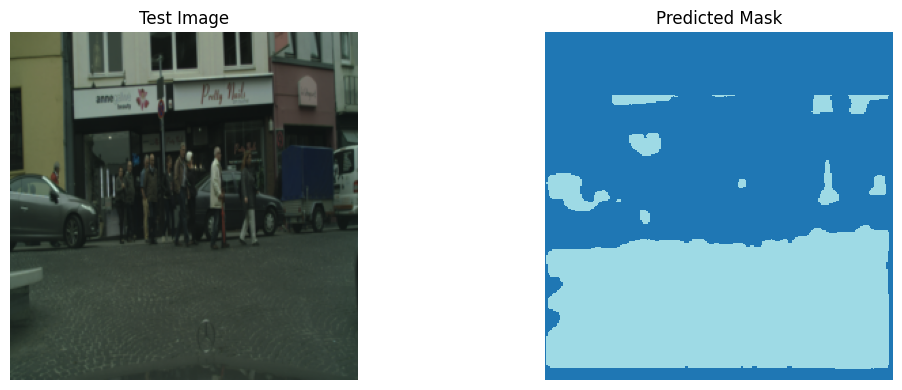

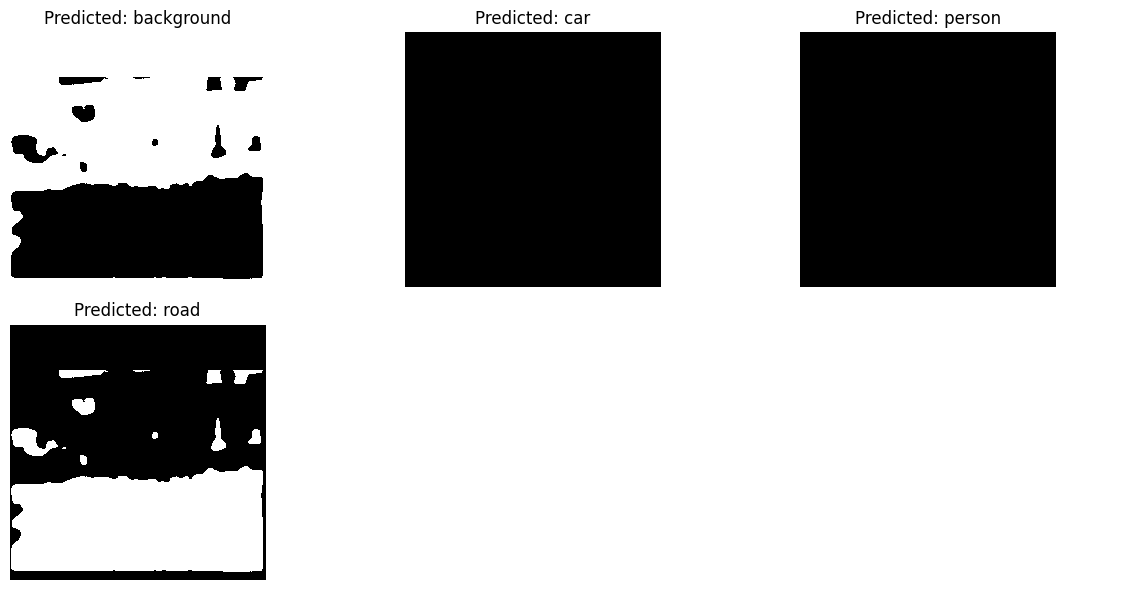

In [36]:
if is_notebook():
    # Result visualisation on test image
    model.eval()

    test_image_path = data_root / 'test_image.png'
    assert test_image_path.exists(), f'Missing test image: {test_image_path}'

    with torch.no_grad():
        image_tensor = train_data.process_image(test_image_path)
        pred_logits = model(image_tensor.unsqueeze(0).to(device)).squeeze(0).cpu()
        pred_mask = torch.argmax(pred_logits, dim=0)

    # Display input and predicted segmentation
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(np.transpose(image_tensor.numpy(), (1, 2, 0)))
    axes[0].set_title('Test Image')
    axes[0].axis('off')

    axes[1].imshow(pred_mask.numpy(), cmap='tab20', interpolation='nearest')
    axes[1].set_title('Predicted Mask')
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Display per-class binary masks
    class_names = train_data.class_names
    n_cls = len(class_names)
    ncols = 3
    nrows = int(np.ceil(n_cls / ncols))
    fig, axs = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
    axs = np.array(axs).reshape(-1)

    for cls_idx, cls_name in enumerate(class_names):
        binary_map = (pred_mask == cls_idx).float().numpy()
        axs[cls_idx].imshow(binary_map, cmap='gray', interpolation='nearest')
        axs[cls_idx].set_title(f'Predicted: {cls_name}')
        axs[cls_idx].axis('off')

    for j in range(n_cls, len(axs)):
        axs[j].axis('off')

    plt.tight_layout()
    plt.show()